# **Importing all essential libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [103]:
csv_path = "symbols_valid_meta.csv.xls"
df = pd.read_csv(csv_path)
df.tail(10)

,Nasdaq Traded,Symbol,Security Name,Listing Exchange,Market Category,ETF,Round Lot Size,Test Issue,Financial Status,CQS Symbol,NASDAQ Symbol,NextShares
8039,Y,ZSL,ProShares UltraShort Silver,P,,Y,100.0,N,NaN,ZSL,ZSL,N
8040,Y,ZTO,"ZTO Express (Cayman) Inc. American Depositary Shares, each representing one Class A ordinary share.",N,,N,100.0,N,NaN,ZTO,ZTO,N
8041,Y,ZTR,Virtus Total Return Fund Inc.,N,,N,100.0,N,NaN,ZTR,ZTR,N
8042,Y,ZTS,Zoetis Inc. Class A Common Stock,N,,N,100.0,N,NaN,ZTS,ZTS,N
8043,Y,ZUMZ,Zumiez Inc. - Common Stock,Q,Q,N,100.0,N,N,NaN,ZUMZ,N
8044,Y,ZUO,"Zuora, Inc. Class A Common Stock",N,,N,100.0,N,NaN,ZUO,ZUO,N
8045,Y,ZVO,Zovio Inc. - Common Stock,Q,Q,N,100.0,N,N,NaN,ZVO,N
8046,Y,ZYME,Zymeworks Inc. Common Shares,N,,N,100.0,N,NaN,ZYME,ZYME,N
8047,Y,ZYNE,"Zynerba Pharmaceuticals, Inc. - Common Stock",Q,G,N,100.0,N,N,NaN,ZYNE,N
8048,Y,ZYXI,"Zynex, Inc. - Common Stock",Q,S,N,100.0,N,N,NaN,ZYXI,N


In [3]:
pd.set_option('display.max_colwidth', None)

## DATA OVERVIEW :

In [4]:
print("Shape:", df.shape)

Shape: (8049, 12)


In [5]:
df.columns

Index(['Nasdaq Traded', 'Symbol', 'Security Name', 'Listing Exchange',
       'Market Category', 'ETF', 'Round Lot Size', 'Test Issue',
       'Financial Status', 'CQS Symbol', 'NASDAQ Symbol', 'NextShares'],
      dtype='object')

## finding the missing values

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8049 entries, 0 to 8048
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Nasdaq Traded     8049 non-null   object 
 1   Symbol            8049 non-null   object 
 2   Security Name     8049 non-null   object 
 3   Listing Exchange  8049 non-null   object 
 4   Market Category   8049 non-null   object 
 5   ETF               8049 non-null   object 
 6   Round Lot Size    8049 non-null   float64
 7   Test Issue        8049 non-null   object 
 8   Financial Status  3383 non-null   object 
 9   CQS Symbol        4666 non-null   object 
 10  NASDAQ Symbol     8049 non-null   object 
 11  NextShares        8049 non-null   object 
dtypes: float64(1), object(11)
memory usage: 754.7+ KB


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe(include='all')

,Nasdaq Traded,Symbol,Security Name,Listing Exchange,Market Category,ETF,Round Lot Size,Test Issue,Financial Status,CQS Symbol,NASDAQ Symbol,NextShares
count,8049,8049,8049,8049,8049,8049,8049.000000,8049,3383,4666,8049,8049
unique,1,8049,8045,5,4,2,NaN,1,4,4666,8049,2
top,Y,ZYXI,iShares Morningstar Mid-Cap ETF,Q,,N,NaN,N,N,ZYME,ZYXI,N
freq,8049,1,2,3383,4666,5884,NaN,8049,3180,1,1,8046
mean,NaN,NaN,NaN,NaN,NaN,NaN,99.942974,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,2.289194,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,100.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,100.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,100.000000,NaN,NaN,NaN,NaN,NaN


### Hypothesis :
1. Most securities in the dataset are financially stable and belong to the Normal (N) financial status category.
2. ETFs are more likely to appear outside traditional Nasdaq market categories (Q, G, S) because they are investment products rather than regular companies.
3. Companies in the Capital Market (S) category are more likely to face financial or compliance issues than companies in higher-tier categories like Q.
Different listing exchanges specialize in different types of securities, with some exchanges being more ETF-focused than others.


### DATA CLEANING : 

### 1. Financial Status

<Axes: xlabel='Financial Status', ylabel='count'>

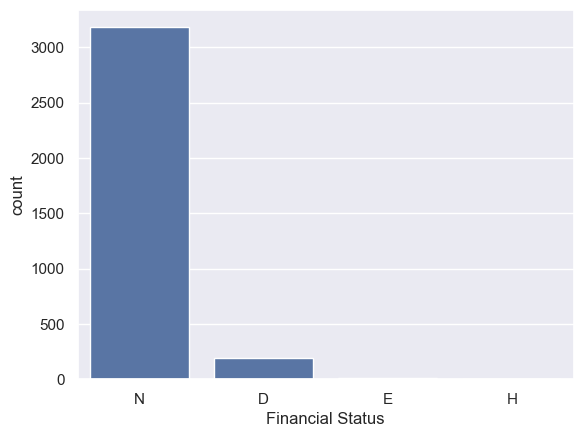

In [9]:
sns.set_style()
sns.set_theme(style='darkgrid')
sns.countplot(x='Financial Status',data=df)

In [10]:
print(df["Financial Status"].unique())

[nan 'N' 'D' 'E' 'H']


| Value | Meaning                        |
| ----- | ------------------------------ |
| N     | Normal / financially compliant |
| D     | Deficient                      |
| E     | Delinquent                     |
| H     | Halted                         |
| NaN   | No value recorded              |


On Nasdaq, problematic companies are usually explicitly flagged with codes like D, E, or H.
So when the value is missing (NaN), it typically means:
**No reported issue = not “information unavailable" = treated as financially normal**

therfore, replacing NaN with "N" (Normal) is reasonable because the absence of a flag generally indicates the company is in normal standing.

In [11]:
df['Financial Status']=df['Financial Status'].fillna('N')

<Axes: xlabel='Financial Status', ylabel='count'>

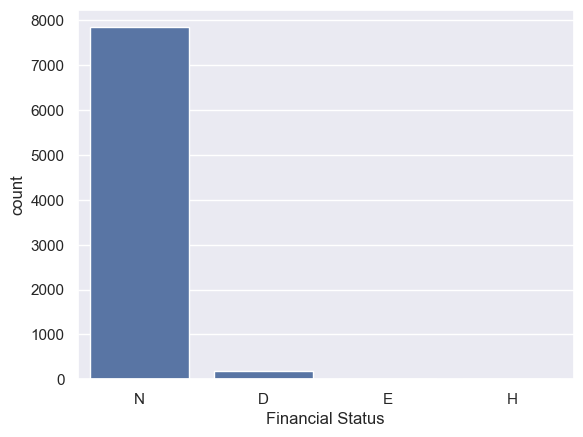

In [12]:
sns.countplot(x='Financial Status',data=df)

The Financial Status column contained a large number of missing values. Instead of treating these values as unknown, they were replaced with “N” (Normal). This decision was based on the structure of Nasdaq reporting, where companies with financial or compliance issues are typically assigned explicit flags such as D (Deficient), E (Delinquent), or H (Halted). Therefore, missing values likely indicate the absence of reported issues rather than missing information. After replacement, the dataset became highly skewed toward financially stable companies, showing that most listed firms meet Nasdaq compliance requirements, while only a small minority exhibit financial distress.

Hypothesis 1 → Accepted

The majority of securities were classified under Financial Status N, confirming that most listed securities are financially stable.

### 2. CQS Symbol:

According to Nasdaq documentation, the CQS Symbol represents the identifier used within the Consolidated Quotation System (CQS), while the Symbol column stores the primary ticker identifier of the security. In practice, both columns referred to the same underlying stock ticker for the vast majority of records in this dataset.
**Source**
https://www.nasdaqtrader.com/trader.aspx?id=symboldirdefs&utm_source=chatgpt.com

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8049 entries, 0 to 8048
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Nasdaq Traded     8049 non-null   object 
 1   Symbol            8049 non-null   object 
 2   Security Name     8049 non-null   object 
 3   Listing Exchange  8049 non-null   object 
 4   Market Category   8049 non-null   object 
 5   ETF               8049 non-null   object 
 6   Round Lot Size    8049 non-null   float64
 7   Test Issue        8049 non-null   object 
 8   Financial Status  8049 non-null   object 
 9   CQS Symbol        4666 non-null   object 
 10  NASDAQ Symbol     8049 non-null   object 
 11  NextShares        8049 non-null   object 
dtypes: float64(1), object(11)
memory usage: 754.7+ KB


In [116]:
df.columns

Index(['Nasdaq Traded', 'Symbol', 'Security Name', 'Listing Exchange',
       'Market Category', 'ETF', 'Round Lot Size', 'Test Issue',
       'Financial Status', 'CQS Symbol', 'NASDAQ Symbol', 'NextShares'],
      dtype='object')

# Univariate Analysis 

###  Nasdaq Traded :

In [16]:
df['Nasdaq Traded'].unique()

array(['Y'], dtype=object)


When we checked the “Nasdaq Traded” column, we found that it contains only a single value, ‘Y’, for all rows in the dataset. This means that every security in the dataset is traded on the Nasdaq Stock Market. However, this does not imply that all companies are listed on Nasdaq, as securities can still be primarily listed on other exchanges but traded through Nasdaq’s systems. 

### Symbol 

In [69]:
df['Symbol'].nunique()

8049

Symbol uniquely identifies tradable security

### Security Name 

In [17]:
df['Security Name'].nunique()

8045

In financial markets, the Security Name is the full company/fund name, while the Symbol is the trading code of a specific security. A company or fund can have multiple tradable share types, so the same Security Name may appear with different Symbols. Therefore, these are valid market entries, not data errors.

### Market Category

In [19]:
df['Market Category'].value_counts(normalize=True)*100

Market Category
     57.969934
Q    19.020996
S    11.827556
G    11.181513
Name: proportion, dtype: float64

To handle the blank (' ') values in the Market Category column, we didn’t treat them as missing information. Instead, we carefully looked at what those blanks actually represent. The categories Q, G, and S are only meant for regular companies listed on the Nasdaq Stock Market. However, many entries in the dataset are ETFs, which are not companies but collections of investments, so they don’t fit into these categories. That’s why we labeled those cases as “ETF” wherever applicable. For the remaining blanks, we used “Not Applicable” to indicate that these securities simply do not belong to the Q/G/S classification system at all, rather than assuming missing or unknown data. This approach keeps the data realistic and avoids forcing incorrect labels, making the feature easier to understand and more reliable for analysis.

In [70]:
df.loc[df['ETF'] == 'Y', 'Market Category'] = 'ETF'
df['Market Category'] = df['Market Category'].replace(' ', 'Not Applicable')

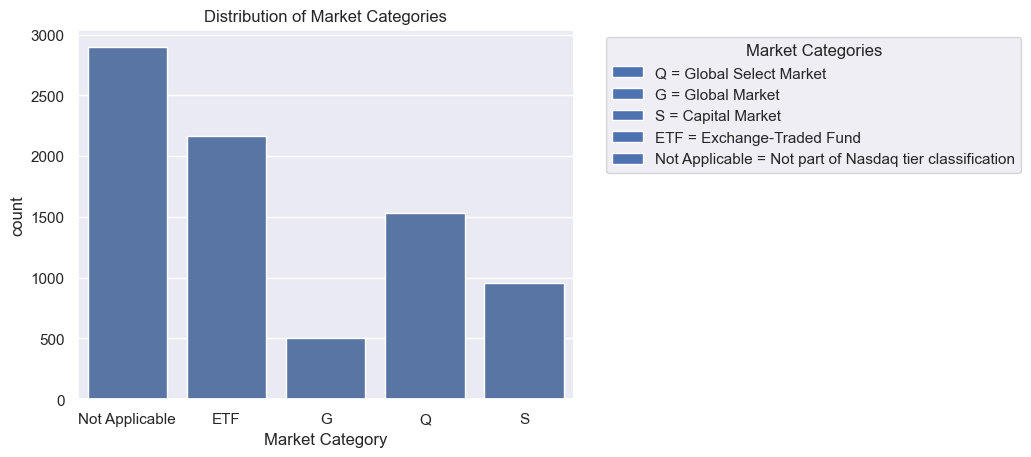

In [71]:
import matplotlib.patches as mpatches
sns.countplot(x='Market Category', data=df)
legend_labels = {
    'Q': 'Global Select Market',
    'G': 'Global Market',
    'S': 'Capital Market',
    'ETF': 'Exchange-Traded Fund',
    'Not Applicable': 'Not part of Nasdaq tier classification'}
# Create legend patches
patches = [
    mpatches.Patch(label=f"{key} = {value}")
    for key, value in legend_labels.items()]
plt.legend(handles=patches,
           title='Market Categories',
           bbox_to_anchor=(1.05, 1),
           loc='upper left')
plt.title('Distribution of Market Categories')
plt.show()

- a very large number of securities (4666) do not belong to Nasdaq’s normal company-tier classification system,
- This security does not belong to Nasdaq’s Q/G/S company-tier classification system.
- Nasdaq me sirf normal companies nahi, balki bahut types ke special investment products bhi listed hote hain.(such as ETFs and other specialized securities.)


## Listing Exchange

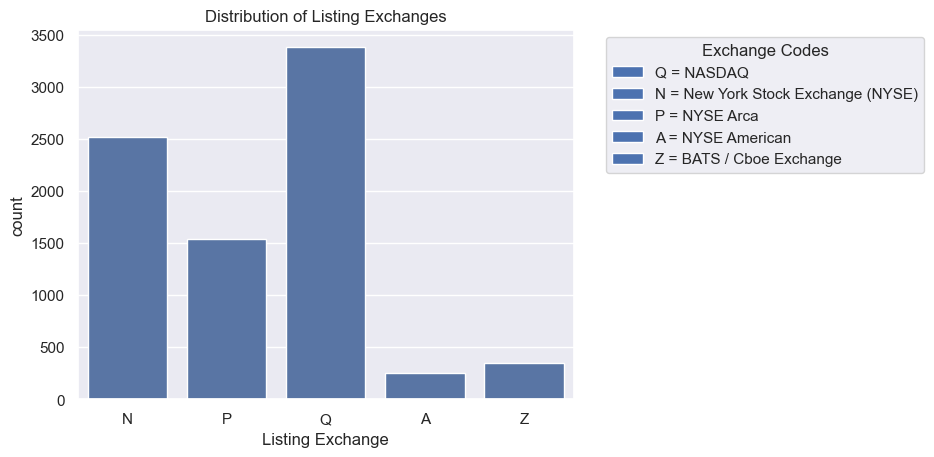

In [72]:
sns.countplot(x='Listing Exchange',data=df)
legend_labels = {
    'Q': 'NASDAQ',
    'N': 'New York Stock Exchange (NYSE)',
    'P': 'NYSE Arca',
    'A': 'NYSE American',
    'Z': 'BATS / Cboe Exchange'}
patches = [
    mpatches.Patch(label=f"{key} = {value}")
    for key, value in legend_labels.items()]

plt.legend(handles=patches, title='Exchange Codes', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Distribution of Listing Exchanges')
plt.show()

1. Most stocks are listed on NASDAQ (Q category), Other exchanges like Z and A have very few listings.

### ETF


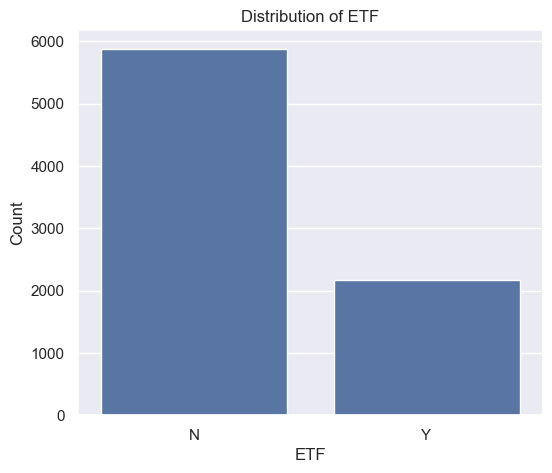

In [73]:
plt.figure(figsize=(6,5))
sns.countplot(x='ETF', data=df)
plt.title("Distribution of ETF")
plt.xlabel("ETF")
plt.ylabel("Count")
plt.show()

Non-ETF securities dominate the dataset. An Exchange Traded Fund (ETF) is an investment fund that is traded in the stock market just like a normal share or stock.

### Round Lot Size

In [74]:
df["Round Lot Size"].value_counts().loc[[1,10]]

Round Lot Size
1.0     1
10.0    4
Name: count, dtype: int64

In [75]:
for i in [1,10]:
    print(f"\nRound Lot Size = {i}\n")
    display(df[df["Round Lot Size"] == i])


Round Lot Size = 1



,Nasdaq Traded,Symbol,Security Name,Listing Exchange,Market Category,ETF,Round Lot Size,Test Issue,Financial Status,NASDAQ Symbol,NextShares
6406,Y,SEB,Seaboard Corporation Common Stock,A,Not Applicable,N,1.0,N,N,SEB,N



Round Lot Size = 10



,Nasdaq Traded,Symbol,Security Name,Listing Exchange,Market Category,ETF,Round Lot Size,Test Issue,Financial Status,NASDAQ Symbol,NextShares
743,Y,BH,Biglari Holdings Inc. Class B Common Stock,N,Not Applicable,N,10.0,N,N,BH,N
1806,Y,DIT,AMCON Distributing Company Common Stock,A,Not Applicable,N,10.0,N,N,DIT,N
4662,Y,MKL,Markel Corporation Common Stock,N,Not Applicable,N,10.0,N,N,MKL,N
5169,Y,NVR,"NVR, Inc. Common Stock",N,Not Applicable,N,10.0,N,N,NVR,N


Round Lot Size means : Shares ka standard trading pack size

Most stocks trade in standard packs of 100 shares, but a few special or expensive company stocks allow smaller trading units like 1 or 10 shares

### Test Issue

In [76]:
df['Test Issue'].unique()

array(['N'], dtype=object)

our dataset contains only real, tradable securitie

### NextShares

separate/special investment products

In [77]:
df['NextShares'].unique()

array(['N', 'Y'], dtype=object)

In [78]:
df[df["NextShares"] == "Y"]

,Nasdaq Traded,Symbol,Security Name,Listing Exchange,Market Category,ETF,Round Lot Size,Test Issue,Financial Status,NASDAQ Symbol,NextShares
2344,Y,EVGBC,Eaton Vance NextShares Trust - Eaton Vance Global Income Builder NextShares,Q,G,N,100.0,N,N,EVGBC,Y
2350,Y,EVLMC,Eaton Vance NextShares Trust II - Eaton Vance TABS 5-to-15 Year Laddered Municipal Bond NextShares,Q,G,N,100.0,N,N,EVLMC,Y
2361,Y,EVSTC,Eaton Vance NextShares Trust - Eaton Vance Stock NextShares,Q,G,N,100.0,N,N,EVSTC,Y


### BIVARIATE ANALYSIS :

### 1. Listing exchange & Financial status -

In [94]:
pd.crosstab(df["Listing Exchange"], df["Financial Status"], dropna=False)

Financial Status,D,E,H,N
Listing Exchange,,,,
A,0,0,0,253
N,0,0,0,2520
P,0,0,0,1542
Q,191,8,4,3180
Z,0,0,0,351


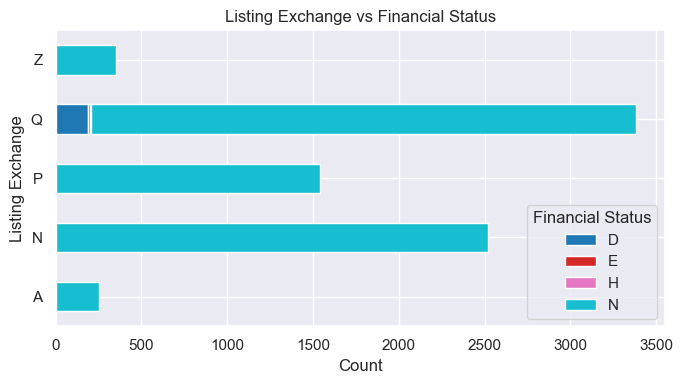

In [87]:
ct.plot(kind='barh',stacked=True,figsize=(7,4),colormap='tab10')
plt.title("Listing Exchange vs Financial Status")
plt.xlabel("Count")
plt.ylabel("Listing Exchange")
plt.tight_layout()
plt.show()

- The Financial Status feature appears to mainly reflect Nasdaq’s own monitoring and compliance system, because warning labels like D, E, and H are only seen for Nasdaq-listed securities (Q) and not for other exchanges. This does not necessarily mean that companies on other exchanges have no risk, but rather that their warning information may not be included in this dataset.


## 2. Listing Exchange & ETF

In [93]:
pd.crosstab(df["Listing Exchange"], df["ETF"], dropna=False)

ETF,N,Y
Listing Exchange,,
A,252,1
N,2520,0
P,107,1435
Q,2988,395
Z,17,334


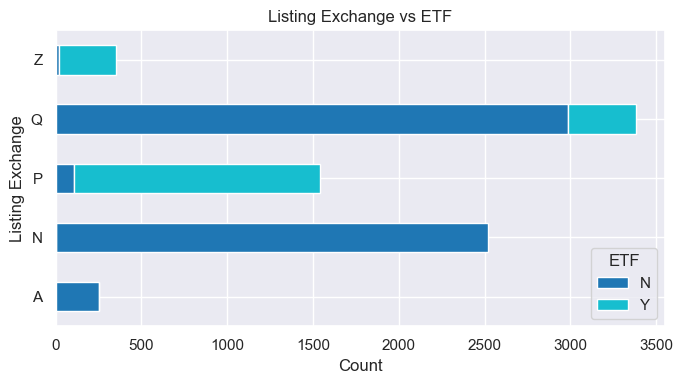

In [99]:
(ct:=pd.crosstab(df["Listing Exchange"],df["ETF"])).plot(
    kind='barh',stacked=True,figsize=(7,4),colormap='tab10')
plt.title("Listing Exchange vs ETF")
plt.xlabel("Count")
plt.ylabel("Listing Exchange")
plt.tight_layout()
plt.show()

This graph shows that different stock exchanges focus on different types of securities.

NYSE mainly has regular company stocks, while exchanges like NYSE Arca and Cboe are dominated by ETFs.

### 3. Financial Status + ETF

In [102]:
pd.crosstab(df["ETF"],df["Financial Status"], dropna=False)

Financial Status,D,E,H,N
ETF,,,,
N,190,8,4,5682
Y,1,0,0,2164


ETFs are generally financially stable investment products.

## 4. ETF & Market category :

In [65]:
pd.crosstab(df["ETF"],df["Market Category"])

Market Category,,G,Q,S
ETF,,,,
N,2896,505,1531,952
Y,1770,395,0,0


- ETFs mostly don’t have company-style market categories
- ETFs are generally structured investment products and are less likely to appear in distressed categories compared to individual operating companies.
- D/E/H mostly matter more for actual companies

Hypothesis 3 → Accepted

Financially distressed securities (D, E, H) were observed more frequently in the S category, indicating relatively higher risk among smaller companies.

## 5 .Financial status and MArket Category :

In [64]:
pd.crosstab(df["Financial Status"],df["Market Category"])

Market Category,,G,Q,S
Financial Status,,,,
D,0,16,11,164
E,0,2,3,3
H,0,0,0,4
N,4666,882,1517,781


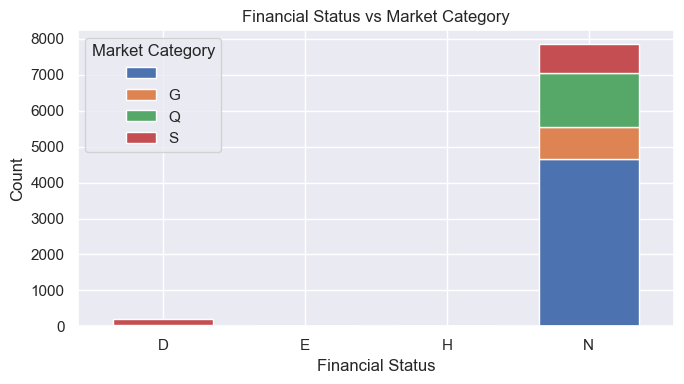

In [53]:
pd.crosstab(df["Financial Status"],df["Market Category"]).plot(
    kind='bar',stacked=True,figsize=(7,4),width=.7)
plt.title("Financial Status vs Market Category")
plt.xlabel("Financial Status")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Most financially stable securities: belong to non-Nasdaq categories(ETF) (blank)
- and smaller/riskier Nasdaq companies have more financial problems.

Hypothesis 3 → Accepted

Financially distressed securities (D, E, H) were observed more frequently in the S category, indicating relatively higher risk among smaller companies.

### 6. Listing Exchange AND Market Category 

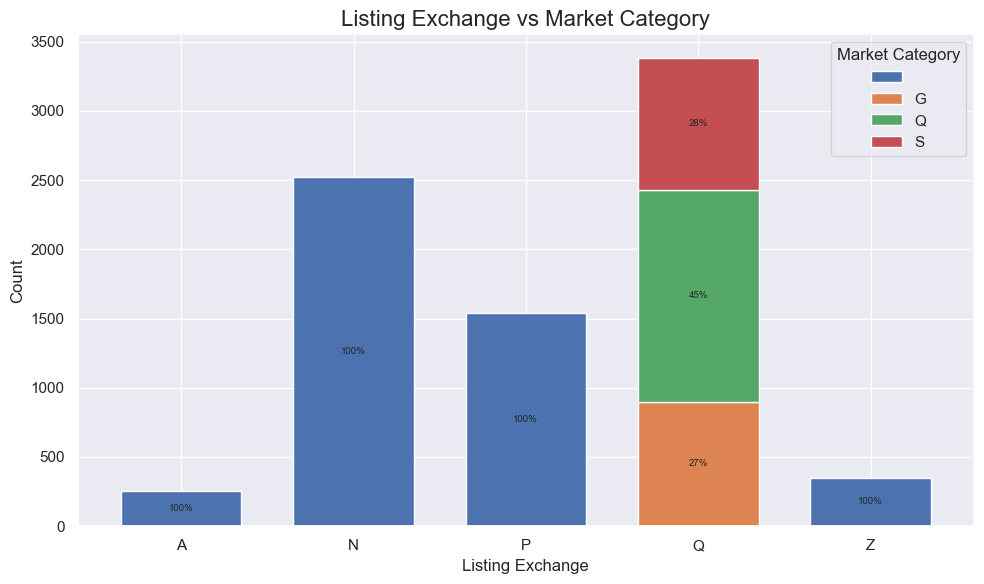

In [45]:
(ct:=pd.crosstab(df["Listing Exchange"],df["Market Category"],dropna=False)).plot(
    kind='bar',stacked=True,figsize=(10,6),width=.7)
t=ct.sum(1)
for c in plt.gca().containers:
    plt.gca().bar_label(
        c,
        labels=[f'{v/t.iloc[i]*100:.0f}%' if v else '' 
                for i,v in enumerate(c.datavalues)],
        label_type='center',fontsize=7)
plt.title("Listing Exchange vs Market Category", fontsize=16)
plt.xlabel("Listing Exchange", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Market Category")
plt.tight_layout()
plt.show()

In [31]:
pd.crosstab(df["Listing Exchange"],df["Market Category"], dropna=False)


Market Category,,G,Q,S
Listing Exchange,,,,
A,253,0,0,0
N,2520,0,0,0
P,1542,0,0,0
Q,0,900,1531,952
Z,351,0,0,0


- Q/G/S categories sirf Nasdaq ke liye hain, isliye dusre exchanges ki securities me Market Category blank hoti hai
- Dataset Nasdaq source se aaya hai, but usme multiple exchanges ki securities hain. Sirf Nasdaq-listed securities par hi Nasdaq ke Q/G/S market categories apply hote hain
- most Nasdaq companies belong to the Global Select Market.

These are: large , established and  financially stronger companies.

### MULTIVARIATE ANALYSIS :

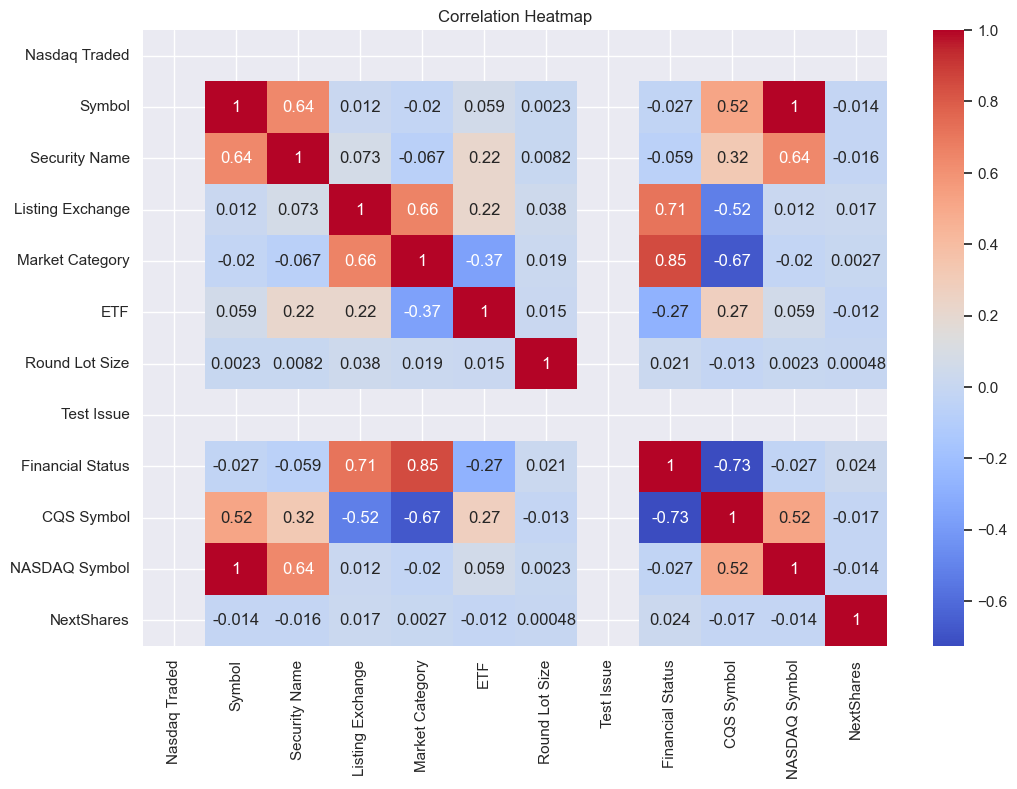

In [110]:
# Encoding categorical columns
encoded_df = df.copy()

for col in encoded_df.select_dtypes(include='object').columns:
    encoded_df[col] = encoded_df[col].astype('category').cat.codes

# Correlation matrix
corr = encoded_df.corr()

# Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.xticks(rotation=90)

plt.title('Correlation Heatmap')
plt.show()

The heatmap shows strong relationships between Listing Exchange, Market Category, and Financial Status, indicating that Nasdaq-specific classifications and warning systems are closely connected. ETFs generally fall outside traditional market categories, while Symbol and NASDAQ Symbol contain almost identical information and are redundant for analysis.

## **Financial Status Insights**
- Most companies and securities in Nasdaq are normal, regulated, and financially stable.
- Only a small number of securities show financial or compliance problems (D/E/H).
- Financial warning labels(D/E) mainly appear in Nasdaq-listed securities. because Financial Status feature mainly Nasdaq-specific monitoring system h.
- Smaller companies me financial/compliance risk zyada dikhta hai.

## **ETF Insights**
- ETFs appear more financially stable compared to individual company stocks.
- Most ETFs fall under the financially normal (N) category.
- ETFs usually fall outside traditional Nasdaq market categories (Q, G, S).
- NYSE Arca and Cboe are strongly ETF-focused exchanges.
- Nasdaq is a mixed exchange containing both regular company stocks and ETF

## **Market Structure Insights**
- Nasdaq contains not only regular companies, but also small firms, ETFs, investment products, and specialized securities.
- Modern stock markets contain many types of securities beyond traditional stocks and ETFs.
- NextShares represent separate/specialized investment products.
- Nasdaq market categories (Q, G, S) are mainly used only for Nasdaq-listed securities.
- Market Category strongly depends on Listing Exchange.

## **Trading Structure Insights**
- Most securities follow the standard 100-share trading structure.
- Round Lot Sizes of 1 and 10 are rare but valid market exceptions.
## **Dataset / Feature Insights**
- Symbol and NASDAQ Symbol contain almost identical information.
- CQS Symbol is also highly similar to Symbol and adds very little unique information.

# Key findings:
1. Most securities are financially stable (N status).
2. ETFs appear more financially stable than regular company stocks.
3. Smaller companies (S category) show relatively higher financial risk.
4. Nasdaq contains diverse securities including stocks, ETFs, and specialized investment products.


## Data Issues / Limitations
- No stock price or historical trend data is available.
- No date/time column for time-series analysis.
- Several features are redundant (NASDAQ Symbol, CQS Symbol).
- Financial Status mainly reflects Nasdaq-specific monitoring.
- Features Needed for Better Analysis
1. Historical stock prices,
2. Trading volume,
3. Market capitalization,
4. Sector/industry information,
5. Financial performance metrics

## Final Conclusion
The dataset reveals that the Nasdaq ecosystem is highly diverse and mostly financially stable, containing traditional company stocks, ETFs, and specialized investment products. Large companies appear more stable, while smaller firms show relatively higher financial risk. Different exchanges focus on different types of securities, and Nasdaq-specific classifications and financial warning systems play a major role in the dataset structure.

Data overview :

Nasdaq Traded: Indicates whether the security is traded through the Nasdaq system (Y = Yes, N = No).
Symbol: Unique short ticker code used to identify a security in the stock market.
Security Name: Full name of the company or financial security.
Listing Exchange: Exchange where the security is officially listed and traded.
Market Category: Nasdaq-specific category (Q, G, S) representing company size and market tier.
ETF: Indicates whether the security is an Exchange-Traded Fund (Y) or a regular security (N).
Round Lot Size: Standard number of shares usually traded together.
Test Issue: Identifies whether the security is a test/demo issue or a real tradable security.
Financial Status: Represents the financial or compliance condition of a security (N, D, E, H).
CQS Symbol: Symbol used in the Consolidated Quotation System for cross-market quotations.
NASDAQ Symbol: Nasdaq-specific ticker symbol, mostly similar to the main Symbol column.
NextShares: Indicates whether the security is a specialized NextShares investment product.